# Analyse comparative — noms propres conservés (ANP) vs retirés (SNP)

## Classification de segments d'œuvres de Zola et du corpus comparatif

Ce notebook met en regard les **sorties enregistrées** de deux expériences :

- **ANP** : noms propres conservés (`zola_vs_naturaliste_ANP.ipynb`) ;
- **SNP** : retrait d'une liste de **493 noms propres** (`zola_vs_naturaliste_SNP.ipynb`).

Les modèles ne sont pas réentraînés ici. Les résultats publiés par les deux notebooks sources sont transcrits dans des structures de données autonomes, contrôlés, puis analysés. Cette séparation permet de relire l'analyse et de régénérer les tableaux et graphiques sans disposer du corpus textuel original.


## Synthèse décisionnelle

> **Configuration recommandée : SNP (retrait des noms propres)** pour une tâche visant la généralisation à des œuvres inédites et, plus encore, l'étude du style.

Les principaux constats sont les suivants :

1. **La régression logistique reste le meilleur modèle** dans les deux configurations.
2. En validation croisée groupée, ANP et SNP sont pratiquement à égalité pour ce modèle : **0,8078 contre 0,8083 de F1 macro**. L'écart de 0,0004 est minuscule au regard de la variabilité entre plis (écarts-types proches de 0,04).
3. Sur le test, SNP améliore la régression logistique : **F1 macro de 0,8286 à 0,8450** (+1,64 point), **accuracy de 0,8402 à 0,8559** (+1,58 point), et **230 erreurs de moins** (2 330 à 2 100, soit −9,9 %).
4. Les neuf œuvres sont correctement classées dans les deux expériences. Avec SNP, la probabilité moyenne accordée à la classe prédite augmente de **0,7318 à 0,7524**, et les neuf œuvres s'éloignent toutes du seuil de décision.
5. La suppression des noms propres réduit fortement l'écart entraînement–validation de la régression logistique (**0,1379 à 0,1050**) sans dégrader la validation. Cela indique que les noms facilitaient surtout l'ajustement au corpus d'entraînement.

Le gain observé sur un unique test de neuf œuvres reste un **signal favorable**, pas une preuve définitive. Une validation répétée au niveau des œuvres est nécessaire pour estimer sa robustesse.


## Provenance des résultats

Les valeurs ci-dessous proviennent exclusivement des sorties visibles dans les deux notebooks sources, lus le 20 juillet 2026.

| Configuration | Notebook source | SHA-256 |
|---|---|---|
| ANP | `zola_vs_naturaliste_ANP.ipynb` | `3da71f452f57e8d42372b8391329aa4141763f73a7af363f956e4c694cf65da4` |
| SNP | `zola_vs_naturaliste_SNP.ipynb` | `024ad167176752a82f9805948c7401d0554dae574bb99b7f32636aa458ba3451` |

Les matrices de confusion sont utilisées pour recalculer indépendamment l'accuracy, les précisions, rappels et F1 de chaque classe. Les agrégats recalculés sont ensuite comparés aux valeurs affichées dans les notebooks sources.


In [1]:
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 60)

COULEURS = {"ANP": "#4C78A8", "SNP": "#F58518"}
ORDRE_MODELES = ["Régression logistique", "Naive Bayes", "LDA"]
ORDRE_CONFIGS = ["ANP", "SNP"]

plt.rcParams.update({
    "figure.figsize": (10, 5.5),
    "figure.dpi": 115,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "font.size": 10,
})

print("Environnement d'analyse chargé.")


Environnement d'analyse chargé.


In [2]:
# Résultats de validation croisée groupée (5 plis)
cv = pd.DataFrame([
    ["ANP", "Régression logistique", 0.807838, 0.037945, 0.815414, 0.945767],
    ["ANP", "Naive Bayes",            0.743335, 0.068347, 0.761669, 0.897636],
    ["ANP", "LDA",                    0.719444, 0.047283, 0.737030, 0.798357],
    ["SNP", "Régression logistique", 0.808250, 0.041721, 0.814674, 0.913242],
    ["SNP", "Naive Bayes",            0.744775, 0.075401, 0.761974, 0.844781],
    ["SNP", "LDA",                    0.716156, 0.053205, 0.734804, 0.765804],
], columns=[
    "configuration", "modèle", "f1_macro_validation", "écart_type_f1",
    "accuracy_validation", "f1_macro_entraînement"
])

# Matrices : lignes = classe réelle, colonnes = classe prédite.
# Ordre des classes : Zola, naturaliste.
confusions = {
    ("ANP", "Naive Bayes"): np.array([[8178, 1340], [1453, 3607]]),
    ("SNP", "Naive Bayes"): np.array([[8268, 1250], [1351, 3709]]),
    ("ANP", "Régression logistique"): np.array([[8020, 1498], [832, 4228]]),
    ("SNP", "Régression logistique"): np.array([[8176, 1342], [758, 4302]]),
    ("ANP", "LDA"): np.array([[8163, 1355], [1611, 3449]]),
    ("SNP", "LDA"): np.array([[8208, 1310], [1647, 3413]]),
}

# Agrégats affichés dans les notebooks sources, utilisés pour le contrôle.
test_source = pd.DataFrame([
    ["ANP", "Régression logistique", 0.840170, 0.828571],
    ["ANP", "Naive Bayes",            0.808410, 0.787520],
    ["ANP", "LDA",                    0.796543, 0.772784],
    ["SNP", "Régression logistique", 0.855947, 0.845001],
    ["SNP", "Naive Bayes",            0.821580, 0.802239],
    ["SNP", "LDA",                    0.797160, 0.772553],
], columns=["configuration", "modèle", "accuracy_source", "f1_macro_source"])

# Probabilités moyennes par œuvre produites par la régression logistique.
oeuvres = pd.DataFrame([
    ["La Faute de l'abbé Mouret", "Zola", 0.740264, 0.746956],
    ["Une page d'amour",           "Zola", 0.672844, 0.738594],
    ["Nana",                       "Zola", 0.736188, 0.740499],
    ["La Bête humaine",            "Zola", 0.763613, 0.774740],
    ["Charles Demailly",           "naturaliste", 0.232875, 0.212898],
    ["En ménage",                  "naturaliste", 0.335568, 0.333194],
    ["Frères Zemganno",            "naturaliste", 0.249648, 0.233061],
    ["Georgette",                  "naturaliste", 0.223562, 0.211609],
    ["Le Père Goriot",             "naturaliste", 0.284735, 0.238307],
], columns=["œuvre", "classe_réelle", "probabilité_Zola_ANP", "probabilité_Zola_SNP"])

print(f"Données figées : {len(cv)} résultats de validation, "
      f"{len(confusions)} matrices de confusion et {len(oeuvres)} œuvres.")


Données figées : 6 résultats de validation, 6 matrices de confusion et 9 œuvres.


# 1. Protocole expérimental commun

La comparaison est une **ablation contrôlée** : le découpage, les segments, le TF-IDF, les plis et les modèles sont identiques. Seule l'utilisation de la liste de noms propres comme mots à exclure change entre ANP et SNP.


In [3]:
protocole = pd.DataFrame([
    ["Corpus total", "49 œuvres"],
    ["Entraînement", "40 œuvres ; 62 312 segments"],
    ["Test", "9 œuvres ; 14 578 segments"],
    ["Unité d'un segment", "Bloc de 3 lignes non vides"],
    ["Découpage train/test", "Mélange fixé par random.seed(1)"],
    ["Validation", "StratifiedGroupKFold, 5 plis, groupes = œuvres, random_state=42"],
    ["TF-IDF", "10 000 traits ; unigrammes + bigrammes ; min_df=2 ; max_df=0,9"],
    ["Modèles", "Naive Bayes ; régression logistique équilibrée ; LDA après SVD(100)"],
    ["Différence ANP/SNP", "SNP ajoute 493 noms propres à stop_words"],
], columns=["Élément", "Paramétrage"])

repartition = pd.DataFrame([
    ["Entraînement", "Zola", 36820],
    ["Entraînement", "naturaliste", 25492],
    ["Test", "Zola", 9518],
    ["Test", "naturaliste", 5060],
], columns=["Partition", "Classe", "Segments"])
repartition["Part dans la partition"] = (
    repartition["Segments"] / repartition.groupby("Partition")["Segments"].transform("sum")
)

print("Paramètres communs")
print(protocole.to_string(index=False))
print("\nRépartition des segments")
repartition.style.format({"Part dans la partition": "{:.1%}"}).hide(axis="index")


Paramètres communs
             Élément                                                         Paramétrage
        Corpus total                                                           49 œuvres
        Entraînement                                         40 œuvres ; 62 312 segments
                Test                                          9 œuvres ; 14 578 segments
  Unité d'un segment                                          Bloc de 3 lignes non vides
Découpage train/test                                     Mélange fixé par random.seed(1)
          Validation     StratifiedGroupKFold, 5 plis, groupes = œuvres, random_state=42
              TF-IDF      10 000 traits ; unigrammes + bigrammes ; min_df=2 ; max_df=0,9
             Modèles Naive Bayes ; régression logistique équilibrée ; LDA après SVD(100)
  Différence ANP/SNP                            SNP ajoute 493 noms propres à stop_words

Répartition des segments


AttributeError: The '.style' accessor requires jinja2

### Lecture du protocole

- Le groupement par œuvre empêche qu'une même œuvre soit simultanément en entraînement et en validation : les cinq sorties indiquent une intersection nulle.
- Les segments restent toutefois **corrélés à l'intérieur d'une œuvre**. Les 14 578 lignes du test ne doivent donc pas être traitées comme 14 578 observations indépendantes pour construire une incertitude statistique.
- Le test est plus déséquilibré que l'entraînement : Zola représente **65,3 %** des segments testés. Le F1 macro est donc la métrique principale la plus pertinente, car il pèse également les deux classes.


# 2. Validation croisée groupée

La validation croisée mesure la capacité à généraliser à des œuvres absentes de l'ajustement, tout en conservant 40 œuvres pour la sélection du modèle.


In [ ]:
cv["écart_entraînement_validation"] = (
    cv["f1_macro_entraînement"] - cv["f1_macro_validation"]
)

lignes_cv = []
for modèle in ORDRE_MODELES:
    anp = cv[(cv["configuration"] == "ANP") & (cv["modèle"] == modèle)].iloc[0]
    snp = cv[(cv["configuration"] == "SNP") & (cv["modèle"] == modèle)].iloc[0]
    lignes_cv.append({
        "modèle": modèle,
        "F1 validation ANP": anp["f1_macro_validation"],
        "F1 validation SNP": snp["f1_macro_validation"],
        "Δ F1 SNP−ANP (points)": 100 * (snp["f1_macro_validation"] - anp["f1_macro_validation"]),
        "écart-type ANP": anp["écart_type_f1"],
        "écart-type SNP": snp["écart_type_f1"],
        "gap train−val ANP": anp["écart_entraînement_validation"],
        "gap train−val SNP": snp["écart_entraînement_validation"],
        "réduction du gap (points)": 100 * (
            anp["écart_entraînement_validation"] - snp["écart_entraînement_validation"]
        ),
    })

comparaison_cv = pd.DataFrame(lignes_cv)
comparaison_cv.style.format({
    "F1 validation ANP": "{:.4f}",
    "F1 validation SNP": "{:.4f}",
    "Δ F1 SNP−ANP (points)": "{:+.3f}",
    "écart-type ANP": "{:.4f}",
    "écart-type SNP": "{:.4f}",
    "gap train−val ANP": "{:.4f}",
    "gap train−val SNP": "{:.4f}",
    "réduction du gap (points)": "{:+.2f}",
}).hide(axis="index")


modèle,F1 validation ANP,F1 validation SNP,Δ F1 SNP−ANP (points),écart-type ANP,écart-type SNP,gap train−val ANP,gap train−val SNP,réduction du gap (points)
Régression logistique,0.8078,0.8083,+0.041,0.0379,0.0417,0.1379,0.1050,+3.29
Naive Bayes,0.7433,0.7448,+0.144,0.0683,0.0754,0.1543,0.1000,+5.43
LDA,0.7194,0.7162,-0.329,0.0473,0.0532,0.0789,0.0496,+2.93


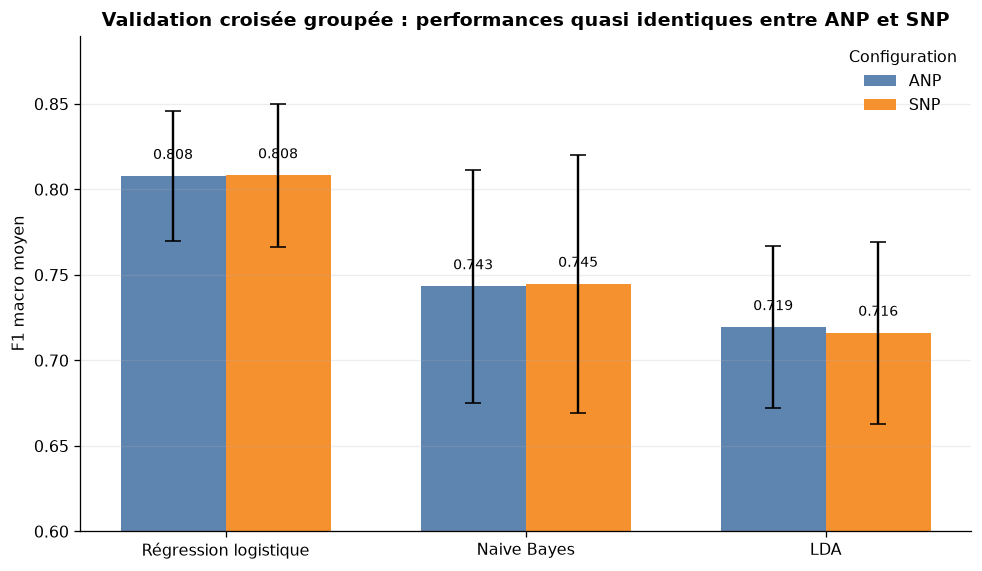

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5.6))
x = np.arange(len(ORDRE_MODELES))
largeur = 0.35

for i, config in enumerate(ORDRE_CONFIGS):
    sous = cv[cv["configuration"] == config].set_index("modèle").loc[ORDRE_MODELES]
    positions = x + (i - 0.5) * largeur
    barres = ax.bar(
        positions,
        sous["f1_macro_validation"],
        largeur,
        yerr=sous["écart_type_f1"],
        capsize=5,
        color=COULEURS[config],
        label=config,
        alpha=0.9,
    )
    for barre, valeur in zip(barres, sous["f1_macro_validation"]):
        ax.text(barre.get_x() + barre.get_width()/2, valeur + 0.008, f"{valeur:.3f}",
                ha="center", va="bottom", fontsize=9)

ax.set_xticks(x, ORDRE_MODELES)
ax.set_ylim(0.60, 0.89)
ax.set_ylabel("F1 macro moyen")
ax.set_title("Validation croisée groupée : performances quasi identiques entre ANP et SNP")
ax.legend(title="Configuration", frameon=False)
ax.grid(axis="y", alpha=0.22)
plt.show()


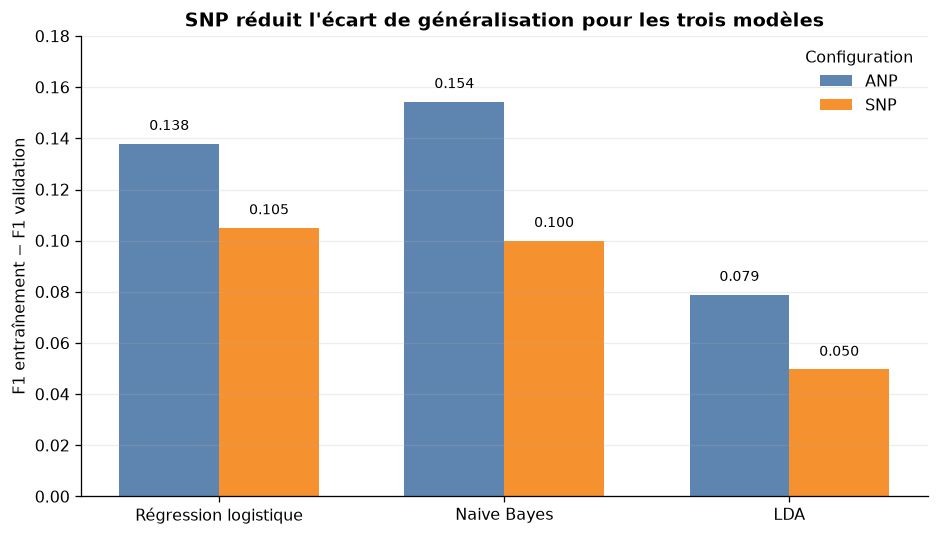

In [ ]:
fig, ax = plt.subplots(figsize=(9.5, 5.2))
x = np.arange(len(ORDRE_MODELES))
largeur = 0.35

for i, config in enumerate(ORDRE_CONFIGS):
    sous = cv[cv["configuration"] == config].set_index("modèle").loc[ORDRE_MODELES]
    valeurs = sous["écart_entraînement_validation"]
    barres = ax.bar(x + (i - 0.5) * largeur, valeurs, largeur,
                    color=COULEURS[config], label=config, alpha=0.9)
    for barre, valeur in zip(barres, valeurs):
        ax.text(barre.get_x() + barre.get_width()/2, valeur + 0.004, f"{valeur:.3f}",
                ha="center", va="bottom", fontsize=9)

ax.set_xticks(x, ORDRE_MODELES)
ax.set_ylim(0, 0.18)
ax.set_ylabel("F1 entraînement − F1 validation")
ax.set_title("SNP réduit l'écart de généralisation pour les trois modèles")
ax.legend(title="Configuration", frameon=False)
ax.grid(axis="y", alpha=0.22)
plt.show()


### Interprétation

La hiérarchie des modèles est stable : **régression logistique > Naive Bayes > LDA**. Pour la régression logistique, le gain SNP en validation n'est que de **0,04 point de F1**, très inférieur aux écarts-types entre plis (3,8 à 4,2 points). Les sorties agrégées ne contiennent pas les cinq scores individuels ; un test apparié ANP–SNP par pli serait donc impossible à reconstruire proprement ici.

En revanche, le comportement d'entraînement change nettement. SNP réduit le gap entraînement–validation de **3,29 points** pour la régression logistique, de **5,43 points** pour Naive Bayes et de **2,93 points** pour LDA. Le retrait agit comme une forme de régularisation lexicale : il supprime des indices très faciles à mémoriser sans diminuer la performance moyenne de validation.


# 3. Résultats sur les 14 578 segments de test

Les métriques sont recalculées à partir des matrices de confusion. Cela fournit un contrôle indépendant des tableaux de sortie originaux.


In [ ]:
classes = ["Zola", "naturaliste"]
résumés = []
détails_classes = []

for (configuration, modèle), matrice in confusions.items():
    total = matrice.sum()
    f1_classes = []
    for i, classe in enumerate(classes):
        tp = int(matrice[i, i])
        fp = int(matrice[:, i].sum() - tp)
        fn = int(matrice[i, :].sum() - tp)
        précision = tp / (tp + fp)
        rappel = tp / (tp + fn)
        f1 = 2 * précision * rappel / (précision + rappel)
        f1_classes.append(f1)
        détails_classes.append({
            "configuration": configuration,
            "modèle": modèle,
            "classe": classe,
            "précision": précision,
            "rappel": rappel,
            "f1": f1,
            "support": int(matrice[i, :].sum()),
        })

    résumés.append({
        "configuration": configuration,
        "modèle": modèle,
        "accuracy": np.trace(matrice) / total,
        "f1_macro": np.mean(f1_classes),
        "erreurs": int(total - np.trace(matrice)),
    })

test = pd.DataFrame(résumés)
par_classe = pd.DataFrame(détails_classes)

contrôle = test.merge(test_source, on=["configuration", "modèle"])
écart_max = max(
    (contrôle["accuracy"] - contrôle["accuracy_source"]).abs().max(),
    (contrôle["f1_macro"] - contrôle["f1_macro_source"]).abs().max(),
)
assert écart_max < 1e-6
print(f"✓ Contrôle réussi : écart maximal avec les sorties sources = {écart_max:.2e}")

lignes_test = []
for modèle in ORDRE_MODELES:
    anp = test[(test["configuration"] == "ANP") & (test["modèle"] == modèle)].iloc[0]
    snp = test[(test["configuration"] == "SNP") & (test["modèle"] == modèle)].iloc[0]
    lignes_test.append({
        "modèle": modèle,
        "F1 ANP": anp["f1_macro"],
        "F1 SNP": snp["f1_macro"],
        "Δ F1 (points)": 100 * (snp["f1_macro"] - anp["f1_macro"]),
        "accuracy ANP": anp["accuracy"],
        "accuracy SNP": snp["accuracy"],
        "Δ accuracy (points)": 100 * (snp["accuracy"] - anp["accuracy"]),
        "erreurs ANP": int(anp["erreurs"]),
        "erreurs SNP": int(snp["erreurs"]),
        "erreurs évitées": int(anp["erreurs"] - snp["erreurs"]),
        "réduction relative des erreurs": (anp["erreurs"] - snp["erreurs"]) / anp["erreurs"],
    })

comparaison_test = pd.DataFrame(lignes_test)
comparaison_test.style.format({
    "F1 ANP": "{:.4f}", "F1 SNP": "{:.4f}", "Δ F1 (points)": "{:+.2f}",
    "accuracy ANP": "{:.4f}", "accuracy SNP": "{:.4f}",
    "Δ accuracy (points)": "{:+.2f}",
    "réduction relative des erreurs": "{:+.1%}",
}).hide(axis="index")


✓ Contrôle réussi : écart maximal avec les sorties sources = 4.64e-07


modèle,F1 ANP,F1 SNP,Δ F1 (points),accuracy ANP,accuracy SNP,Δ accuracy (points),erreurs ANP,erreurs SNP,erreurs évitées,réduction relative des erreurs
Régression logistique,0.8286,0.8450,+1.64,0.8402,0.8559,+1.58,2330,2100,230,+9.9%
Naive Bayes,0.7875,0.8022,+1.47,0.8084,0.8216,+1.32,2793,2601,192,+6.9%
LDA,0.7728,0.7726,-0.02,0.7965,0.7972,+0.06,2966,2957,9,+0.3%


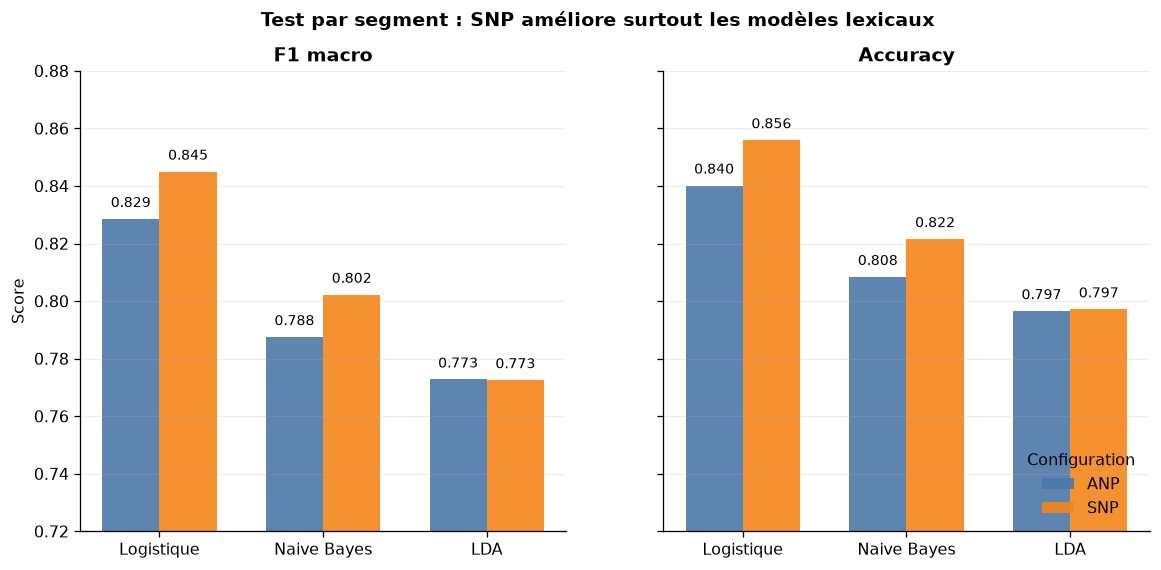

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharey=True)
mesures = [("f1_macro", "F1 macro"), ("accuracy", "Accuracy")]
x = np.arange(len(ORDRE_MODELES))
largeur = 0.35

for ax, (colonne, titre) in zip(axes, mesures):
    for i, config in enumerate(ORDRE_CONFIGS):
        sous = test[test["configuration"] == config].set_index("modèle").loc[ORDRE_MODELES]
        barres = ax.bar(x + (i - 0.5) * largeur, sous[colonne], largeur,
                        color=COULEURS[config], label=config, alpha=0.9)
        for barre, valeur in zip(barres, sous[colonne]):
            ax.text(barre.get_x() + barre.get_width()/2, valeur + 0.003,
                    f"{valeur:.3f}", ha="center", va="bottom", fontsize=8.5)
    ax.set_xticks(x, ["Logistique", "Naive Bayes", "LDA"])
    ax.set_title(titre)
    ax.set_ylim(0.72, 0.88)
    ax.grid(axis="y", alpha=0.22)

axes[0].set_ylabel("Score")
axes[1].legend(title="Configuration", frameon=False, loc="lower right")
fig.suptitle("Test par segment : SNP améliore surtout les modèles lexicaux", fontweight="bold")
plt.show()


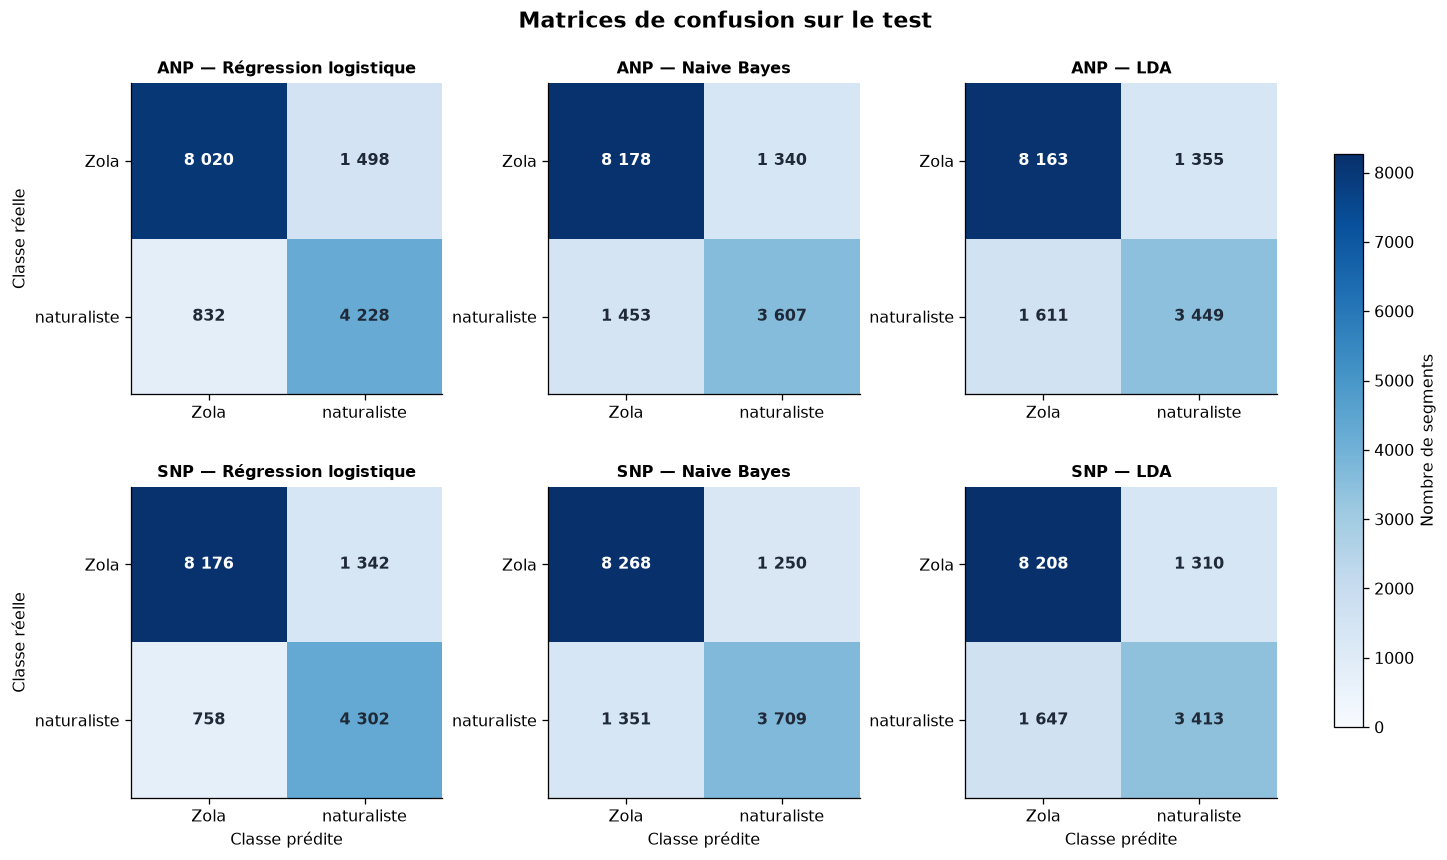

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12.5, 7.5), constrained_layout=True)
maximum = max(m.max() for m in confusions.values())

for ligne, config in enumerate(ORDRE_CONFIGS):
    for colonne, modèle in enumerate(ORDRE_MODELES):
        ax = axes[ligne, colonne]
        matrice = confusions[(config, modèle)]
        image = ax.imshow(matrice, cmap="Blues", vmin=0, vmax=maximum)
        for i in range(2):
            for j in range(2):
                couleur = "white" if matrice[i, j] > maximum * 0.55 else "#1f2937"
                ax.text(j, i, f"{matrice[i, j]:,}".replace(",", " "),
                        ha="center", va="center", color=couleur, fontweight="bold")
        ax.set_xticks([0, 1], ["Zola", "naturaliste"])
        ax.set_yticks([0, 1], ["Zola", "naturaliste"])
        ax.set_title(f"{config} — {modèle}", fontsize=10)
        if ligne == 1:
            ax.set_xlabel("Classe prédite")
        if colonne == 0:
            ax.set_ylabel("Classe réelle")

fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.72, label="Nombre de segments")
fig.suptitle("Matrices de confusion sur le test", fontsize=14, fontweight="bold")
plt.show()


In [ ]:
f1_classe = (
    par_classe.pivot(index=["modèle", "classe"], columns="configuration", values="f1")
    .reset_index()
)
f1_classe["Δ SNP−ANP (points)"] = 100 * (f1_classe["SNP"] - f1_classe["ANP"])
f1_classe["ordre"] = f1_classe["modèle"].map({m: i for i, m in enumerate(ORDRE_MODELES)})
f1_classe = f1_classe.sort_values(["ordre", "classe"]).drop(columns="ordre")

f1_classe.style.format({
    "ANP": "{:.3f}", "SNP": "{:.3f}", "Δ SNP−ANP (points)": "{:+.2f}"
}).hide(axis="index")


modèle,classe,ANP,SNP,Δ SNP−ANP (points)
Régression logistique,Zola,0.873,0.886,+1.30
Régression logistique,naturaliste,0.784,0.804,+1.98
Naive Bayes,Zola,0.854,0.864,+0.99
Naive Bayes,naturaliste,0.721,0.740,+1.95
LDA,Zola,0.846,0.847,+0.11
LDA,naturaliste,0.699,0.698,-0.16


### Interprétation du test

- **Régression logistique** : SNP améliore le F1 des deux classes, avec un gain plus fort pour `naturaliste` (**+1,98 point**) que pour Zola (**+1,30 point**). La matrice montre 156 segments de Zola et 74 segments naturalistes correctement récupérés en plus.
- **Naive Bayes** : le gain est également bilatéral ; 192 erreurs sont évitées, soit **−6,9 %**.
- **LDA** : l'effet est nul à l'échelle utile. Neuf erreurs seulement sont évitées, tandis que le F1 macro baisse très légèrement (−0,02 point). La réduction SVD n'explique que 14,7 % de la variance dans les deux notebooks, ce qui limite probablement ce modèle plus que la gestion des noms propres.

Le fait que SNP aide surtout les deux modèles directement fondés sur les poids lexicaux est cohérent avec la nature de l'ablation.


# 4. Évaluation au niveau des œuvres

Les probabilités des segments ont été moyennées par œuvre dans les notebooks sources. Le seuil de décision est 0,5 : au-dessus, l'œuvre est prédite Zola ; en dessous, `naturaliste`.


In [ ]:
for config in ORDRE_CONFIGS:
    p = oeuvres[f"probabilité_Zola_{config}"]
    oeuvres[f"prédiction_{config}"] = np.where(p >= 0.5, "Zola", "naturaliste")
    oeuvres[f"confiance_{config}"] = np.where(p >= 0.5, p, 1 - p)

oeuvres["Δ probabilité Zola"] = oeuvres["probabilité_Zola_SNP"] - oeuvres["probabilité_Zola_ANP"]
oeuvres["Δ confiance"] = oeuvres["confiance_SNP"] - oeuvres["confiance_ANP"]

assert (oeuvres["prédiction_ANP"] == oeuvres["classe_réelle"]).all()
assert (oeuvres["prédiction_SNP"] == oeuvres["classe_réelle"]).all()
assert (oeuvres["Δ confiance"] > 0).all()

vue_oeuvres = oeuvres[[
    "œuvre", "classe_réelle", "probabilité_Zola_ANP", "probabilité_Zola_SNP",
    "Δ probabilité Zola", "confiance_ANP", "confiance_SNP", "Δ confiance"
]]

print("✓ 9/9 œuvres correctement classées dans les deux configurations.")
print(f"Confiance moyenne ANP : {oeuvres['confiance_ANP'].mean():.4f}")
print(f"Confiance moyenne SNP : {oeuvres['confiance_SNP'].mean():.4f}")
print(f"Gain moyen de confiance : {oeuvres['Δ confiance'].mean():+.4f}")

vue_oeuvres.style.format({
    "probabilité_Zola_ANP": "{:.3f}", "probabilité_Zola_SNP": "{:.3f}",
    "Δ probabilité Zola": "{:+.3f}", "confiance_ANP": "{:.3f}",
    "confiance_SNP": "{:.3f}", "Δ confiance": "{:+.3f}",
}).hide(axis="index")


✓ 9/9 œuvres correctement classées dans les deux configurations.
Confiance moyenne ANP : 0.7318
Confiance moyenne SNP : 0.7524
Gain moyen de confiance : +0.0206


œuvre,classe_réelle,probabilité_Zola_ANP,probabilité_Zola_SNP,Δ probabilité Zola,confiance_ANP,confiance_SNP,Δ confiance
La Faute de l'abbé Mouret,Zola,0.740,0.747,+0.007,0.740,0.747,+0.007
Une page d'amour,Zola,0.673,0.739,+0.066,0.673,0.739,+0.066
Nana,Zola,0.736,0.740,+0.004,0.736,0.740,+0.004
La Bête humaine,Zola,0.764,0.775,+0.011,0.764,0.775,+0.011
Charles Demailly,naturaliste,0.233,0.213,-0.020,0.767,0.787,+0.020
En ménage,naturaliste,0.336,0.333,-0.002,0.664,0.667,+0.002
Frères Zemganno,naturaliste,0.250,0.233,-0.017,0.750,0.767,+0.017
Georgette,naturaliste,0.224,0.212,-0.012,0.776,0.788,+0.012
Le Père Goriot,naturaliste,0.285,0.238,-0.046,0.715,0.762,+0.046


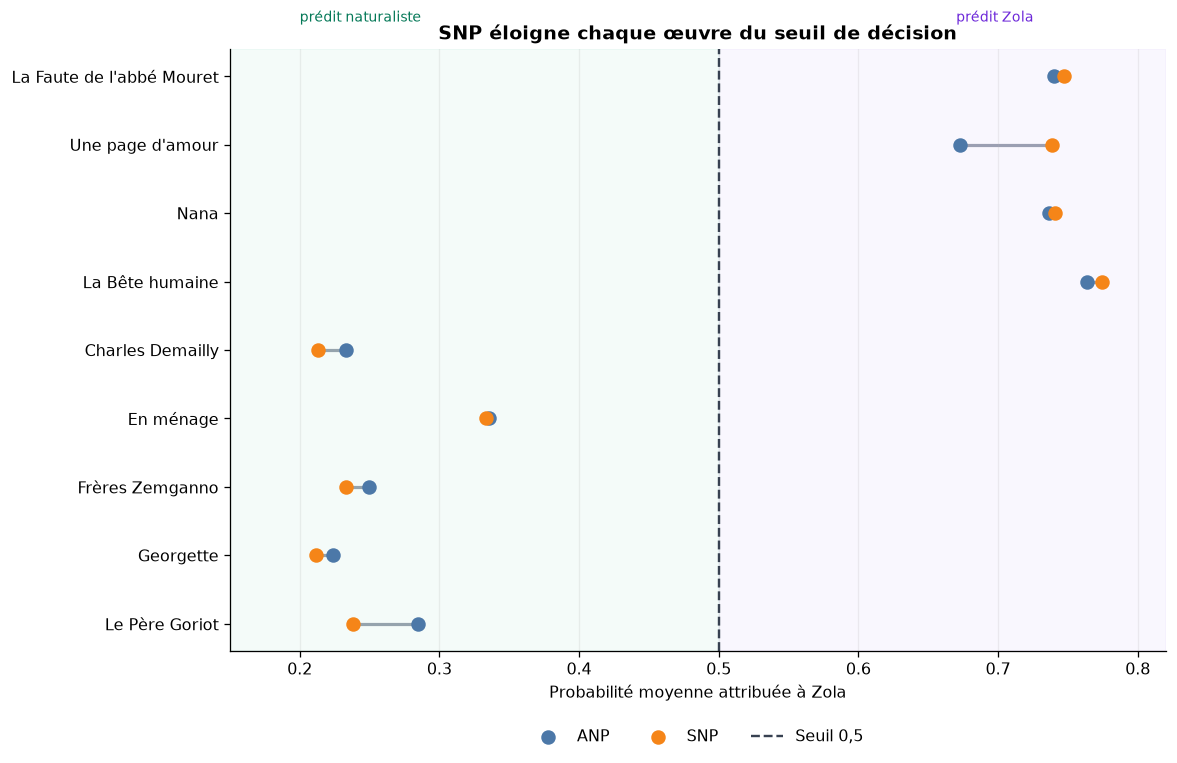

In [ ]:
fig, ax = plt.subplots(figsize=(10.5, 6.8))
y = np.arange(len(oeuvres))

for i, ligne in oeuvres.iterrows():
    ax.plot(
        [ligne["probabilité_Zola_ANP"], ligne["probabilité_Zola_SNP"]],
        [i, i], color="#9CA3AF", linewidth=2, zorder=1
    )

ax.scatter(oeuvres["probabilité_Zola_ANP"], y, s=65, color=COULEURS["ANP"],
           label="ANP", zorder=3)
ax.scatter(oeuvres["probabilité_Zola_SNP"], y, s=65, color=COULEURS["SNP"],
           label="SNP", zorder=3)
ax.axvline(0.5, color="#374151", linestyle="--", linewidth=1.5, label="Seuil 0,5")
ax.axvspan(0.15, 0.5, color="#10B981", alpha=0.045)
ax.axvspan(0.5, 0.82, color="#8B5CF6", alpha=0.045)
ax.text(0.20, -0.8, "prédit naturaliste", color="#047857", fontsize=9)
ax.text(0.67, -0.8, "prédit Zola", color="#6D28D9", fontsize=9)
ax.set_yticks(y, oeuvres["œuvre"])
ax.invert_yaxis()
ax.set_xlim(0.15, 0.82)
ax.set_xlabel("Probabilité moyenne attribuée à Zola")
ax.set_title("SNP éloigne chaque œuvre du seuil de décision")
ax.legend(frameon=False, ncol=3, loc="lower center", bbox_to_anchor=(0.5, -0.18))
ax.grid(axis="x", alpha=0.20)
plt.show()


In [ ]:
# Intervalle de Wilson à 95 % pour 9 succès sur 9 œuvres.
def intervalle_wilson(succès, n, z=1.959963984540054):
    p = succès / n
    dénominateur = 1 + z**2 / n
    centre = (p + z**2 / (2*n)) / dénominateur
    demi_largeur = z * math.sqrt(p*(1-p)/n + z**2/(4*n**2)) / dénominateur
    return centre - demi_largeur, centre + demi_largeur

borne_basse, borne_haute = intervalle_wilson(9, 9)
pd.DataFrame([{
    "œuvres correctes": 9,
    "œuvres testées": 9,
    "accuracy observée": 1.0,
    "borne basse Wilson 95 %": borne_basse,
    "borne haute Wilson 95 %": borne_haute,
}]).style.format({
    "accuracy observée": "{:.1%}",
    "borne basse Wilson 95 %": "{:.1%}",
    "borne haute Wilson 95 %": "{:.1%}",
}).hide(axis="index")


œuvres correctes,œuvres testées,accuracy observée,borne basse Wilson 95 %,borne haute Wilson 95 %
9,9,100.0%,70.1%,100.0%


### Interprétation par œuvre

SNP renforce la décision pour les **neuf œuvres**, dans le bon sens pour chacune. Le changement le plus marqué concerne *Une page d'amour* (+0,0658 de probabilité Zola), suivi du *Père Goriot* (−0,0464 de probabilité Zola, donc confiance naturaliste accrue).

Cependant, 9/9 ne signifie pas que l'accuracy réelle est connue avec précision : l'intervalle de Wilson à 95 % est approximativement **[70,1 % ; 100 %]**. Le plus petit éloignement au seuil reste modéré (0,1668 avec SNP, pour *En ménage*). La perfection apparente doit donc rester secondaire par rapport aux validations multi-œuvres répétées.


# 5. Ce que révèlent les indices lexicaux

Les termes les plus discriminants changent profondément lorsque les noms propres sont retirés. Cette section reprend les premières positions affichées dans les notebooks sources ; elle décrit les paramètres appris, sans prétendre fournir une explication causale de chaque prédiction.


In [ ]:
couverture = pd.DataFrame([
    ["ANP", 0,   10000, 9705],
    ["SNP", 493, 10000, 9886],
], columns=["configuration", "noms retirés", "taille du vocabulaire", "termes présents dans le test"])
couverture["couverture du vocabulaire"] = (
    couverture["termes présents dans le test"] / couverture["taille du vocabulaire"]
)
gain_termes = int(couverture.loc[1, "termes présents dans le test"] - couverture.loc[0, "termes présents dans le test"])

print(f"SNP rend {gain_termes} traits supplémentaires du vocabulaire observables dans le test ")
print("(+1,81 point de couverture).")
couverture.style.format({"couverture du vocabulaire": "{:.2%}"}).hide(axis="index")


SNP rend 181 traits supplémentaires du vocabulaire observables dans le test 
(+1,81 point de couverture).


configuration,noms retirés,taille du vocabulaire,termes présents dans le test,couverture du vocabulaire
ANP,0,10000,9705,97.05%
SNP,493,10000,9886,98.86%


In [ ]:
nb_termes = pd.DataFrame({
    "rang": range(1, 13),
    "ANP — Zola": [
        "rougon", "mouret", "gervaise", "saccard", "coupeau", "pauline",
        "denise", "étienne", "buteau", "octave", "florent", "faujas"
    ],
    "SNP — Zola": [
        "prussiens", "empereur", "sedan", "les prussiens", "coron", "zingueur",
        "insurgés", "les camarades", "le zingueur", "nom dieu", "foutre", "mineurs"
    ],
    "ANP — naturaliste": [
        "gérard", "joachim", "madame gérard", "birotteau", "jé", "arnoux",
        "durtal", "mathéus", "du quesnoy", "quesnoy", "allart", "duroy"
    ],
    "SNP — naturaliste": [
        "jé", "dé", "barbier", "le barbier", "dis je", "lé",
        "mé", "quelle avait", "dor", "quelle ne", "cé", "écrie"
    ],
})

print("Douze termes les plus caractéristiques selon Naive Bayes")
nb_termes.style.hide(axis="index")


Douze termes les plus caractéristiques selon Naive Bayes


rang,ANP — Zola,SNP — Zola,ANP — naturaliste,SNP — naturaliste
1,rougon,prussiens,gérard,jé
2,mouret,empereur,joachim,dé
3,gervaise,sedan,madame gérard,barbier
4,saccard,les prussiens,birotteau,le barbier
5,coupeau,coron,jé,dis je
6,pauline,zingueur,arnoux,lé
7,denise,insurgés,durtal,mé
8,étienne,les camarades,mathéus,quelle avait
9,buteau,le zingueur,du quesnoy,dor
10,octave,nom dieu,quesnoy,quelle ne


In [ ]:
lr_termes = pd.DataFrame({
    "rang": range(1, 13),
    "ANP — Zola (coef. < 0)": [
        "rougon", "saccard", "mouret", "pauline", "claude", "lorsque",
        "gervaise", "octave", "renée", "maxime", "plassans", "denise"
    ],
    "SNP — Zola (coef. < 0)": [
        "lorsque", "empereur", "qu elle", "ça", "hein", "simplement",
        "lorsqu", "ce fut", "dut", "tout un", "ce pas", "oncle"
    ],
    "ANP — naturaliste (coef. > 0)": [
        "et", "frédéric", "joachim", "jeanne", "duroy", "durtal",
        "quelle", "birotteau", "tout coup", "arnoux", "emma", "émile"
    ],
    "SNP — naturaliste (coef. > 0)": [
        "et", "quelle", "tout coup", "ou", "dit", "esprit",
        "répliqua", "point", "soudain", "aussitôt", "théâtre", "se dit"
    ],
})

print("Douze coefficients les plus extrêmes de la régression logistique")
lr_termes.style.hide(axis="index")


Douze coefficients les plus extrêmes de la régression logistique


rang,ANP — Zola (coef. < 0),SNP — Zola (coef. < 0),ANP — naturaliste (coef. > 0),SNP — naturaliste (coef. > 0)
1,rougon,lorsque,et,et
2,saccard,empereur,frédéric,quelle
3,mouret,qu elle,joachim,tout coup
4,pauline,ça,jeanne,ou
5,claude,hein,duroy,dit
6,lorsque,simplement,durtal,esprit
7,gervaise,lorsqu,quelle,répliqua
8,octave,ce fut,birotteau,point
9,renée,dut,tout coup,soudain
10,maxime,tout un,arnoux,aussitôt


In [ ]:
contributions = pd.DataFrame([
    ["ANP", "vers Zola", "nana",  518.947609],
    ["ANP", "vers Zola", "elle",  226.339002],
    ["ANP", "vers Zola", "eugène", 159.336785],
    ["ANP", "vers naturaliste", "je",     -274.281291],
    ["ANP", "vers naturaliste", "jeanne", -274.194611],
    ["ANP", "vers naturaliste", "vous",   -205.732834],
    ["SNP", "vers Zola", "elle",  238.606649],
    ["SNP", "vers Zola", "ça",    143.429962],
    ["SNP", "vers Zola", "était", 133.713991],
    ["SNP", "vers naturaliste", "je",   -277.189085],
    ["SNP", "vers naturaliste", "vous", -208.686927],
    ["SNP", "vers naturaliste", "et",   -171.320328],
], columns=["configuration", "direction", "terme", "contribution globale dans le test"])

contributions.style.format({"contribution globale dans le test": "{:+.2f}"}).hide(axis="index")


configuration,direction,terme,contribution globale dans le test
ANP,vers Zola,nana,+518.95
ANP,vers Zola,elle,+226.34
ANP,vers Zola,eugène,+159.34
ANP,vers naturaliste,je,-274.28
ANP,vers naturaliste,jeanne,-274.19
ANP,vers naturaliste,vous,-205.73
SNP,vers Zola,elle,+238.61
SNP,vers Zola,ça,+143.43
SNP,vers Zola,était,+133.71
SNP,vers naturaliste,je,-277.19


### Interprétation lexicale

Avec ANP, les premières positions de Naive Bayes sont presque entièrement occupées par des personnages : `rougon`, `mouret`, `gervaise`, `saccard` d'un côté ; `gérard`, `joachim`, `birotteau`, `arnoux` de l'autre. La régression logistique présente le même phénomène. Dans le test, `nana` devient même la plus forte contribution globale vers Zola (**518,95**), tandis que `jeanne` est l'une des contributions les plus fortes vers l'autre classe (**−274,19**).

Après retrait, les coefficients font davantage apparaître :

- des habitudes syntaxiques ou discursives (`lorsque`, `qu elle`, `tout coup`, `répliqua`) ;
- des marqueurs de registre (`ça`, `hein`, `nom dieu`, `foutre`) ;
- des indices thématiques (`prussiens`, `empereur`, `mineurs`, `théâtre`) ;
- des formes dialectales, éditoriales ou possiblement bruitées (`jé`, `dé`, `lé`, `mé`, `dor`).

SNP ne produit donc pas une mesure de « style pur ». Il réduit un biais manifeste lié aux personnages, mais laisse subsister thèmes, lieux, archaïsmes, variantes dialectales, segmentation et particularités d'édition. La présence résiduelle de noms tels que `Vuillet`, `Cazenove` ou `Larsonneau` dans les listes complètes indique aussi que la liste de 493 entrées n'est pas exhaustive.

Enfin, le nombre de traits du vocabulaire vus dans le test passe de **9 705 à 9 886**. Une interprétation plausible est que les noms occupaient une partie des 10 000 places disponibles au détriment de termes plus transférables ; cette explication demanderait toutefois une analyse directe des vocabulaires pour être confirmée.


# 6. Limites méthodologiques

1. **Un seul découpage final.** Les neuf œuvres testées proviennent d'un tirage fixé. Le gain SNP peut dépendre de leur composition.
2. **Peu d'unités réellement indépendantes.** Le test contient beaucoup de segments, mais seulement neuf œuvres. Les métriques par segment surpondèrent mécaniquement les œuvres longues.
3. **Scores par pli indisponibles.** Les moyennes et écarts-types ne permettent pas de reconstruire une comparaison appariée ANP–SNP ni un intervalle fiable du gain.
4. **Liste de noms imparfaite.** Le retrait repose sur `patronime.json` et une liste manuelle. Des noms restent présents ; des mots ambigus peuvent aussi être retirés alors qu'ils ne sont pas toujours des noms propres.
5. **Étiquette littéraire à préciser.** `naturaliste` est une étiquette opérationnelle du corpus. Le test inclut notamment *Le Père Goriot*, généralement classé parmi les romans réalistes. Pour éviter une conclusion historique trop large, `autres auteurs` ou `corpus comparatif` serait une dénomination plus rigoureuse.
6. **Interprétation post-hoc.** Les listes de termes et contributions globales décrivent le modèle et le corpus, mais ne constituent ni une causalité littéraire ni une explication locale complète.


# 7. Conclusion et suite recommandée

| Critère | Résultat | Avantage |
|---|---|---|
| F1 macro en validation groupée | 0,8078 ANP vs 0,8083 SNP | Égalité pratique |
| Surapprentissage | Gap logistique 0,1379 ANP vs 0,1050 SNP | **SNP** |
| F1 macro au test | 0,8286 ANP vs 0,8450 SNP | **SNP** |
| Erreurs de la régression logistique | 2 330 ANP vs 2 100 SNP | **SNP** |
| Accuracy par œuvre | 9/9 dans les deux cas | Égalité |
| Confiance moyenne par œuvre | 0,7318 ANP vs 0,7524 SNP | **SNP** |
| Interprétabilité stylistique | ANP dominé par les personnages | **SNP**, avec réserves |

**Conclusion :** les noms propres n'apportent aucun gain de validation, accroissent l'ajustement au train et dégradent le meilleur modèle sur le test observé. La configuration **SNP avec régression logistique** constitue donc le meilleur choix parmi les six combinaisons étudiées.

Pour consolider ce résultat :

1. enregistrer les cinq scores de chaque pli pour une comparaison appariée ANP–SNP ;
2. répéter des découpages groupés par œuvre, ou employer une validation de type leave-one-work-out ;
3. rapporter systématiquement les métriques par œuvre et par segment ;
4. auditer la liste de noms et mesurer séparément noms de personnes, lieux et titres ;
5. comparer avec des n-grammes de caractères, souvent utiles en attribution d'auteur et moins dépendants des personnages ;
6. renommer ou documenter précisément la classe `naturaliste` selon le périmètre littéraire visé.
